# LSTM Carbon Intensity Forecasting — v2 (with Exogenous Features)

**Improvements over v1:**
- Added **wind speed** (DMI) — most important feature for Denmark's wind-heavy grid
- Added **temperature** (DMI) — drives heating demand
- Added **solar radiation** (DMI) — correlates with solar generation
- Added **day-ahead electricity price** — encodes market expectations
- Added **wind power generation** (offshore + onshore from Energi Data Service)
- Added **solar power generation** (from Energi Data Service)
- Added **renewable share %** — computed from electricity production data
- Added **day-of-week** encoding (sin/cos)
- Kept all original features: carbon intensity, diff_1, diff_24, hour, season encodings

**Expected improvement:** From ~34.5% MAPE (univariate) to significantly lower, especially at longer forecast horizons (hours 12-24).


# Imports & Configuration

In [21]:
import os
import glob
import json
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
print(f"TensorFlow: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")


TensorFlow: 2.20.0
GPU available: False


In [22]:
# ─── Paths ───
EMISSIONS_PATH   = "../emissions-data"
WEATHER_PATH     = "../weather"
PRICES_PATH      = "../prices"
ELEC_PROD_PATH   = "../electricity-prod"

TARGET_COL = "Carbon intensity gCO₂eq/kWh (direct)"

# ─── Model hyperparameters ───
WINDOW_SIZE        = 168          # 7 days of hourly history
FORECAST_HORIZON   = 24           # predict next 24 hours
HIDDEN_SIZE        = 128          # increased from 64 — more features need more capacity
NUM_LAYERS         = 2
DROPOUT            = 0.3
LEARNING_RATE      = 0.001
EPOCHS             = 50
BATCH_SIZE         = 64

LOG_DIR    = "logs_lstm_v2"
MODEL_DIR  = "saved_model_lstm_v2"
TFLITE_PATH = "carbon_model_lstm_v2.tflite"

os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)


# Load Carbon Intensity Data (Target)

In [23]:
csv_files = sorted(glob.glob(os.path.join(EMISSIONS_PATH, "*.csv")))
df = pd.concat(
    (pd.read_csv(f, parse_dates=["Datetime (UTC)"]) for f in csv_files),
    ignore_index=True
)
df = df.sort_values("Datetime (UTC)").reset_index(drop=True)

# Keep only the columns we need
df = df[["Datetime (UTC)", TARGET_COL]].copy()

print(f"Emissions data: {len(df)} rows")
print(f"Date range: {df['Datetime (UTC)'].min()} to {df['Datetime (UTC)'].max()}")
df.head()


Emissions data: 43824 rows
Date range: 2021-01-01 00:00:00 to 2025-12-31 23:00:00


,Datetime (UTC),Carbon intensity gCO₂eq/kWh (direct)
0,2021-01-01 00:00:00,124.66
1,2021-01-01 01:00:00,111.30
2,2021-01-01 02:00:00,108.22
3,2021-01-01 03:00:00,111.48
4,2021-01-01 04:00:00,118.55


# Load Weather Data (DMI)

Weather data has multiple stations. We'll aggregate by taking the **median across all stations** 
for each hour — this gives a robust Denmark-wide estimate that isn't skewed by outliers 
from individual stations.


In [24]:
def load_dmi_data(pattern, value_col, new_name):
    """Load DMI weather CSVs, aggregate across stations to hourly Denmark-wide values."""
    files = sorted(glob.glob(os.path.join(WEATHER_PATH, pattern)))
    if not files:
        print(f"  ⚠️  No files found for pattern: {pattern}")
        return pd.DataFrame()
    
    dfs = []
    for f in files:
        try:
            d = pd.read_csv(f)
            dfs.append(d)
        except Exception as e:
            print(f"  ⚠️  Could not read {f}: {e}")

    if not dfs:
        return pd.DataFrame()

    weather = pd.concat(dfs, ignore_index=True)

    # Parse datetime manually — handles timezone-aware strings like "2025-01-01 02:00:00+00:00"
    weather["timeObserved"] = pd.to_datetime(weather["timeObserved"], format="ISO8601", utc=True)
    # Remove timezone info so it matches emissions data (which is tz-naive UTC)
    weather["timeObserved"] = weather["timeObserved"].dt.tz_localize(None)

    # Floor to hour (some observations are at odd minutes)
    weather["hour_utc"] = weather["timeObserved"].dt.floor("h")

    # Aggregate: median across all stations per hour
    hourly = weather.groupby("hour_utc")[value_col].median().reset_index()
    hourly.columns = ["Datetime (UTC)", new_name]
    
    print(f"  {new_name}: {len(hourly)} hours from {len(files)} files, "
          f"{weather['stationId'].nunique()} stations")
    
    return hourly

print("Loading DMI weather data...")
wind_df = load_dmi_data("*_dmi_wind*", "mean_wind_speed", "wind_speed")
temp_df = load_dmi_data("*_dmi_temp*", "mean_temp", "temperature")
sun_df  = load_dmi_data("*_dmi_sun*",  "mean_radiation", "solar_radiation")


Loading DMI weather data...
  wind_speed: 52609 hours from 6 files, 57 stations
  temperature: 52609 hours from 6 files, 61 stations
  solar_radiation: 52595 hours from 6 files, 29 stations


# Load Day-Ahead Electricity Prices

In [25]:
price_files = sorted(glob.glob(os.path.join(PRICES_PATH, "DayAheadPrices_DK1_*.csv")))
print(f"Found {len(price_files)} price files")

price_dfs = []
for f in price_files:
    try:
        d = pd.read_csv(f)
        price_dfs.append(d)
    except Exception as e:
        print(f"  ⚠️  Could not read {f}: {e}")

prices = pd.concat(price_dfs, ignore_index=True)

# Parse the datetime from "MTU (UTC)" column
# Format: "31/12/2020 23:00:00 - 01/01/2021 00:00:00"
# We take the START of each interval
prices["Datetime (UTC)"] = pd.to_datetime(
    prices["MTU (UTC)"].str.split(" - ").str[0],
    format="%d/%m/%Y %H:%M:%S"
)
prices = prices[["Datetime (UTC)", "Day-ahead Price (EUR/MWh)"]].copy()
prices.columns = ["Datetime (UTC)", "price_eur_mwh"]

# Drop duplicates and sort
prices = prices.drop_duplicates(subset="Datetime (UTC)").sort_values("Datetime (UTC)")
prices = prices.reset_index(drop=True)

print(f"Prices: {len(prices)} hours, {prices['Datetime (UTC)'].min()} to {prices['Datetime (UTC)'].max()}")
prices.head()


Found 5 price files
Prices: 41303 hours, 2020-12-31 23:00:00 to 2025-09-17 21:00:00


,Datetime (UTC),price_eur_mwh
0,2020-12-31 23:00:00,50.87
1,2021-01-01 00:00:00,48.19
2,2021-01-01 01:00:00,44.68
3,2021-01-01 02:00:00,42.92
4,2021-01-01 03:00:00,40.39


# Load Electricity Production Data (Energi Data Service)

This is 5-minute resolution data. We need to:
1. Sum DK1 + DK2 to get all-Denmark totals
2. Resample from 5-min to hourly (mean)
3. Compute renewable share = (wind + solar) / total production


In [26]:
import os
# Check what's actually in the electricity-prod folder
elec_dir = "../electricity-prod"
if os.path.exists(elec_dir):
    print("Files in", elec_dir)
    for f in os.listdir(elec_dir):
        print(f"  {f}")
else:
    print(f"Folder '{elec_dir}' does not exist")
    # Check parent directory to see what folders are available
    print("\nFolders in parent directory:")
    for f in sorted(os.listdir("..")):
        print(f"  {f}")

Files in ../electricity-prod
  electricity_prod_2021.csv
  electricity_prod_2022.csv
  electricity_prod_2023.csv
  electricity_prod_2024.csv
  electricity_prod_2025.csv
  electricity_prod_2026.csv


In [27]:
elec_files = sorted(glob.glob(os.path.join(ELEC_PROD_PATH, "electricity_prod_*.csv")))
print(f"Found {len(elec_files)} electricity files")

elec_dfs = []
for f in elec_files:
    try:
        d = pd.read_csv(f, parse_dates=["Minutes5UTC"])
        elec_dfs.append(d)
    except Exception as e:
        print(f"  ⚠️  Could not read {f}: {e}")

elec = pd.concat(elec_dfs, ignore_index=True)

print(f"Electricity production: {len(elec)} rows ({elec['PriceArea'].unique()})")

# Sum DK1 + DK2 for each 5-minute interval
# (production columns are additive across price areas)
prod_cols = ["ProductionLt100MW", "ProductionGe100MW", 
             "OffshoreWindPower", "OnshoreWindPower", "SolarPower"]

elec_sum = elec.groupby("Minutes5UTC")[prod_cols].sum().reset_index()

# Resample to hourly (mean of the 12 five-minute intervals per hour)
elec_sum = elec_sum.set_index("Minutes5UTC")
elec_hourly = elec_sum.resample("1h").mean().reset_index()
elec_hourly.columns = ["Datetime (UTC)"] + prod_cols

# Compute derived features
elec_hourly["total_wind"]  = elec_hourly["OffshoreWindPower"] + elec_hourly["OnshoreWindPower"]
elec_hourly["total_production"] = (elec_hourly["ProductionLt100MW"] + 
                                    elec_hourly["ProductionGe100MW"] +
                                    elec_hourly["OffshoreWindPower"] + 
                                    elec_hourly["OnshoreWindPower"] + 
                                    elec_hourly["SolarPower"])

# Renewable share (avoid division by zero)
elec_hourly["renewable_share"] = np.where(
    elec_hourly["total_production"] > 0,
    (elec_hourly["total_wind"] + elec_hourly["SolarPower"]) / elec_hourly["total_production"],
    0.0
)

# Keep only the features we want
elec_features = elec_hourly[["Datetime (UTC)", "total_wind", "SolarPower", "renewable_share"]].copy()
elec_features.columns = ["Datetime (UTC)", "wind_power_mw", "solar_power_mw", "renewable_share"]

print(f"Electricity hourly: {len(elec_features)} rows")
print(f"Date range: {elec_features['Datetime (UTC)'].min()} to {elec_features['Datetime (UTC)'].max()}")
elec_features.head()


Found 6 electricity files
Electricity production: 1087688 rows (<StringArray>
['DK1', 'DK2']
Length: 2, dtype: str)
Electricity hourly: 45372 rows
Date range: 2020-12-31 23:00:00 to 2026-03-06 10:00:00


,Datetime (UTC),wind_power_mw,solar_power_mw,renewable_share
0,2020-12-31 23:00:00,589.101668,0.0,0.229192
1,2021-01-01 00:00:00,510.819167,0.0,0.208472
2,2021-01-01 01:00:00,465.147500,0.0,0.209772
3,2021-01-01 02:00:00,408.981667,0.0,0.199443
4,2021-01-01 03:00:00,344.724167,0.0,0.175672


# Merge All Datasets

All datasets are hourly and keyed on `Datetime (UTC)`. We do left joins from the 
carbon intensity data (our target) to keep only hours where we have carbon intensity values.


In [28]:
# Start with emissions as the base
merged = df.copy()

# Merge weather
for weather_df in [wind_df, temp_df, sun_df]:
    if len(weather_df) > 0:
        merged = merged.merge(weather_df, on="Datetime (UTC)", how="left")

# Merge prices
merged = merged.merge(prices, on="Datetime (UTC)", how="left")

# Merge electricity production
merged = merged.merge(elec_features, on="Datetime (UTC)", how="left")

# ─── Add time features ───
merged["hour"] = merged["Datetime (UTC)"].dt.hour
merged["day_of_year"] = merged["Datetime (UTC)"].dt.dayofyear
merged["day_of_week"] = merged["Datetime (UTC)"].dt.dayofweek

# Cyclical encodings
merged["hour_sin"]  = np.sin(2 * np.pi * merged["hour"] / 24)
merged["hour_cos"]  = np.cos(2 * np.pi * merged["hour"] / 24)
merged["year_sin"]  = np.sin(2 * np.pi * merged["day_of_year"] / 365.25)
merged["year_cos"]  = np.cos(2 * np.pi * merged["day_of_year"] / 365.25)
merged["dow_sin"]   = np.sin(2 * np.pi * merged["day_of_week"] / 7)
merged["dow_cos"]   = np.cos(2 * np.pi * merged["day_of_week"] / 7)

# ─── Add differencing features ───
merged["diff_1"]  = merged[TARGET_COL].diff(1)
merged["diff_24"] = merged[TARGET_COL].diff(24)

# Drop NaN rows from differencing and missing merges
merged = merged.dropna().reset_index(drop=True)

print(f"Merged dataset: {len(merged)} rows")
print(f"Date range: {merged['Datetime (UTC)'].min()} to {merged['Datetime (UTC)'].max()}")
print(f"\nColumns ({len(merged.columns)}):")
for col in merged.columns:
    null_pct = merged[col].isna().mean() * 100
    print(f"  {col:45s}  nulls: {null_pct:.1f}%  range: [{merged[col].min():.2f}, {merged[col].max():.2f}]"
          if merged[col].dtype in ['float64', 'int64'] else f"  {col}")


Merged dataset: 41261 rows
Date range: 2021-01-02 00:00:00 to 2025-09-17 21:00:00

Columns (20):
  Datetime (UTC)
  Carbon intensity gCO₂eq/kWh (direct)           nulls: 0.0%  range: [12.55, 456.96]
  wind_speed                                     nulls: 0.0%  range: [0.60, 16.90]
  temperature                                    nulls: 0.0%  range: [-10.55, 30.00]
  solar_radiation                                nulls: 0.0%  range: [0.00, 866.50]
  price_eur_mwh                                  nulls: 0.0%  range: [-440.10, 936.28]
  wind_power_mw                                  nulls: 0.0%  range: [-67.36, 6502.56]
  solar_power_mw                                 nulls: 0.0%  range: [-0.74, 3504.67]
  renewable_share                                nulls: 0.0%  range: [-0.00, 0.96]
  hour
  day_of_year
  day_of_week
  hour_sin                                       nulls: 0.0%  range: [-1.00, 1.00]
  hour_cos                                       nulls: 0.0%  range: [-1.00, 1.00]
  yea

# Feature Selection & Data Split

**New features (v2):** wind_speed, temperature, solar_radiation, price_eur_mwh, 
wind_power_mw, solar_power_mw, renewable_share, dow_sin, dow_cos

These are added on top of the original 7 features from v1.


In [29]:
FEATURES = [
    # ─── Original v1 features ───
    TARGET_COL,            # carbon intensity (target is also an input — autoregressive)
    "diff_1",              # 1-hour change
    "diff_24",             # 24-hour change
    "hour_sin", "hour_cos",
    "year_sin", "year_cos",
    
    # ─── NEW: Weather (DMI) ───
    "wind_speed",          # most important for Denmark's wind-heavy grid
    "temperature",         # drives heating demand
    "solar_radiation",     # correlates with solar generation
    
    # ─── NEW: Market ───
    "price_eur_mwh",       # day-ahead electricity price
    
    # ─── NEW: Grid state (Energi Data Service) ───
    "wind_power_mw",       # actual wind generation (offshore + onshore)
    "solar_power_mw",      # actual solar generation
    "renewable_share",     # fraction of production from renewables
    
    # ─── NEW: Day of week ───
    "dow_sin", "dow_cos",
]

print(f"Total features: {len(FEATURES)}")
for i, f in enumerate(FEATURES):
    print(f"  [{i:2d}] {f}")


Total features: 16
  [ 0] Carbon intensity gCO₂eq/kWh (direct)
  [ 1] diff_1
  [ 2] diff_24
  [ 3] hour_sin
  [ 4] hour_cos
  [ 5] year_sin
  [ 6] year_cos
  [ 7] wind_speed
  [ 8] temperature
  [ 9] solar_radiation
  [10] price_eur_mwh
  [11] wind_power_mw
  [12] solar_power_mw
  [13] renewable_share
  [14] dow_sin
  [15] dow_cos


# Split Data (same as v1: train 2021-2023, val 2024, test 2025)

In [30]:
train = merged[(merged["Datetime (UTC)"].dt.year >= 2021) &
               (merged["Datetime (UTC)"].dt.year <= 2023)]
val = merged[merged["Datetime (UTC)"].dt.year == 2024]
test = merged[merged["Datetime (UTC)"].dt.year == 2025]

print(f"Train: {len(train)} rows ({train['Datetime (UTC)'].min().date()} to {train['Datetime (UTC)'].max().date()})")
print(f"Val:   {len(val)} rows ({val['Datetime (UTC)'].min().date()} to {val['Datetime (UTC)'].max().date()})")
print(f"Test:  {len(test)} rows ({test['Datetime (UTC)'].min().date()} to {test['Datetime (UTC)'].max().date()})")


Train: 26241 rows (2021-01-02 to 2023-12-31)
Val:   8784 rows (2024-01-01 to 2024-12-31)
Test:  6236 rows (2025-01-01 to 2025-09-17)


# Normalization

**Same approach as v1:** Scale ALL features together using one StandardScaler. 
This is critical for LSTM — sigmoid gates saturate on mixed-scale inputs.


In [31]:
feature_scaler = StandardScaler()

train = train.copy()
val = val.copy()
test = test.copy()

train[FEATURES] = feature_scaler.fit_transform(train[FEATURES])
val[FEATURES]   = feature_scaler.transform(val[FEATURES])
test[FEATURES]  = feature_scaler.transform(test[FEATURES])

# Extract target-only scaler for inverse_transform at inference
target_idx = FEATURES.index(TARGET_COL)
target_scaler = StandardScaler()
target_scaler.mean_ = np.array([feature_scaler.mean_[target_idx]])
target_scaler.scale_ = np.array([feature_scaler.scale_[target_idx]])
target_scaler.var_ = np.array([feature_scaler.var_[target_idx]])
target_scaler.n_features_in_ = 1
target_scaler.n_samples_seen_ = feature_scaler.n_samples_seen_

# Save scaler parameters for Android
scaler_params = {
    "target_mean": target_scaler.mean_.tolist(),
    "target_scale": target_scaler.scale_.tolist(),
    "feature_names": FEATURES,
    "feature_means": feature_scaler.mean_.tolist(),
    "feature_scales": feature_scaler.scale_.tolist(),
}
with open("scaler_params_v2.json", "w") as f:
    json.dump(scaler_params, f, indent=4)

print(f"Target scaler — mean: {target_scaler.mean_[0]:.2f}, scale: {target_scaler.scale_[0]:.2f}")
print(f"\nAll feature means/scales:")
for i, feat in enumerate(FEATURES):
    print(f"  {feat:40s}: mean={feature_scaler.mean_[i]:8.2f}, scale={feature_scaler.scale_[i]:8.2f}")


Target scaler — mean: 119.08, scale: 63.90

All feature means/scales:
  Carbon intensity gCO₂eq/kWh (direct)    : mean=  119.08, scale=   63.90
  diff_1                                  : mean=   -0.00, scale=   15.17
  diff_24                                 : mean=   -0.03, scale=   48.91
  hour_sin                                : mean=   -0.00, scale=    0.71
  hour_cos                                : mean=   -0.00, scale=    0.71
  year_sin                                : mean=    0.00, scale=    0.71
  year_cos                                : mean=   -0.00, scale=    0.71
  wind_speed                              : mean=    4.50, scale=    2.21
  temperature                             : mean=    9.48, scale=    6.48
  solar_radiation                         : mean=  125.04, scale=  198.04
  price_eur_mwh                           : mean=  131.40, scale=  114.44
  wind_power_mw                           : mean= 2037.21, scale= 1473.84
  solar_power_mw                          

# Create Windowed Dataset

In [32]:
def create_dataset(data):
    x, y = [], []
    values = data[FEATURES].values
    target = data[TARGET_COL].values

    for i in range(WINDOW_SIZE, len(data) - FORECAST_HORIZON):
        x.append(values[i-WINDOW_SIZE:i])
        y.append(target[i:i+FORECAST_HORIZON])

    return np.array(x), np.array(y)

x_train, y_train = create_dataset(train)
x_val, y_val = create_dataset(val)
x_test, y_test = create_dataset(test)

print(f"x_train: {x_train.shape} | y_train: {y_train.shape}")
print(f"x_val:   {x_val.shape}  | y_val:   {y_val.shape}")
print(f"x_test:  {x_test.shape}  | y_test:  {y_test.shape}")

# Sanity check: all features should be ~mean 0, std 1
print(f"\nFeature stats in x_train (should all be ~mean 0, std 1):")
for i, f in enumerate(FEATURES):
    vals = x_train[:, :, i].flatten()
    print(f"  {f:40s}: mean={vals.mean():.3f}, std={vals.std():.3f}")


x_train: (26049, 168, 16) | y_train: (26049, 24)
x_val:   (8592, 168, 16)  | y_val:   (8592, 24)
x_test:  (6044, 168, 16)  | y_test:  (6044, 24)

Feature stats in x_train (should all be ~mean 0, std 1):
  Carbon intensity gCO₂eq/kWh (direct)    : mean=0.000, std=1.002
  diff_1                                  : mean=-0.000, std=1.002
  diff_24                                 : mean=-0.000, std=1.002
  hour_sin                                : mean=-0.000, std=1.000
  hour_cos                                : mean=-0.000, std=1.000
  year_sin                                : mean=-0.000, std=1.004
  year_cos                                : mean=-0.010, std=0.996
  wind_speed                              : mean=-0.003, std=0.999
  temperature                             : mean=0.007, std=1.000
  solar_radiation                         : mean=0.004, std=1.002
  price_eur_mwh                           : mean=0.006, std=1.001
  wind_power_mw                           : mean=-0.005, std=0.9

# Build LSTM Model (v2)

**Changes from v1:**
- HIDDEN_SIZE increased from 64 → 128 (more features need more capacity)
- Input features: 7 → 17


In [33]:
num_features = len(FEATURES)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(WINDOW_SIZE, num_features)),

    # LSTM layer 1 — captures long-range temporal dependencies
    tf.keras.layers.LSTM(
        HIDDEN_SIZE,
        return_sequences=True,
        unroll=True,
        kernel_regularizer=tf.keras.regularizers.l2(1e-4)
    ),
    tf.keras.layers.Dropout(DROPOUT),

    # LSTM layer 2 — compresses sequence to single vector
    tf.keras.layers.LSTM(
        HIDDEN_SIZE,
        return_sequences=False,
        unroll=True,
        kernel_regularizer=tf.keras.regularizers.l2(1e-4)
    ),
    tf.keras.layers.Dropout(DROPOUT),

    # Dense head
    tf.keras.layers.Dense(HIDDEN_SIZE, activation="relu"),
    tf.keras.layers.Dropout(DROPOUT),
    tf.keras.layers.Dense(FORECAST_HORIZON)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="mse",
    metrics=["mae"]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 168, 128)       │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 168, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,432 (880.59 KB)

 Trainable params: 225,432 (880.59 KB)

 Non-trainable params: 0 (0.00 B)

# Callbacks

In [34]:
tensorboard_cb = tf.keras.callbacks.TensorBoard(log_dir=LOG_DIR)

csv_logger = tf.keras.callbacks.CSVLogger("training_log_lstm_v2.csv")

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=7,              # slightly more patience — new features may need more epochs
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(MODEL_DIR, "best_model.keras"),
    monitor="val_loss",
    save_best_only=True
)


# Train

In [35]:
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[tensorboard_cb, csv_logger, early_stop, reduce_lr, checkpoint]
)


Epoch 1/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 145s 207ms/step - loss: 0.4084 - mae: 0.4633 - val_loss: 0.2601 - val_mae: 0.3715 - learning_rate: 0.0010
Epoch 2/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 75s 185ms/step - loss: 0.3102 - mae: 0.4086 - val_loss: 0.2838 - val_mae: 0.3993 - learning_rate: 0.0010
Epoch 3/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 75s 184ms/step - loss: 0.2481 - mae: 0.3686 - val_loss: 0.2852 - val_mae: 0.3847 - learning_rate: 0.0010
Epoch 4/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 71s 173ms/step - loss: 0.1970 - mae: 0.3288 - val_loss: 0.2937 - val_mae: 0.3914 - learning_rate: 0.0010
Epoch 5/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 61s 151ms/step - loss: 0.1545 - mae: 0.2893 - val_loss: 0.3393 - val_mae: 0.4185 - learning_rate: 5.0000e-04
Epoch 6/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 46s 112ms/step - loss: 0.1367 - mae: 0.2713 - val_loss: 0.3462 - val_mae: 0.4323 - learning_rate: 5.0000e-04
Epoch 7/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 46s 112ms/step - loss: 0.1329 - mae: 0.2647 - val_loss: 0.3808 - val_mae: 0.4458 

# Training Curves

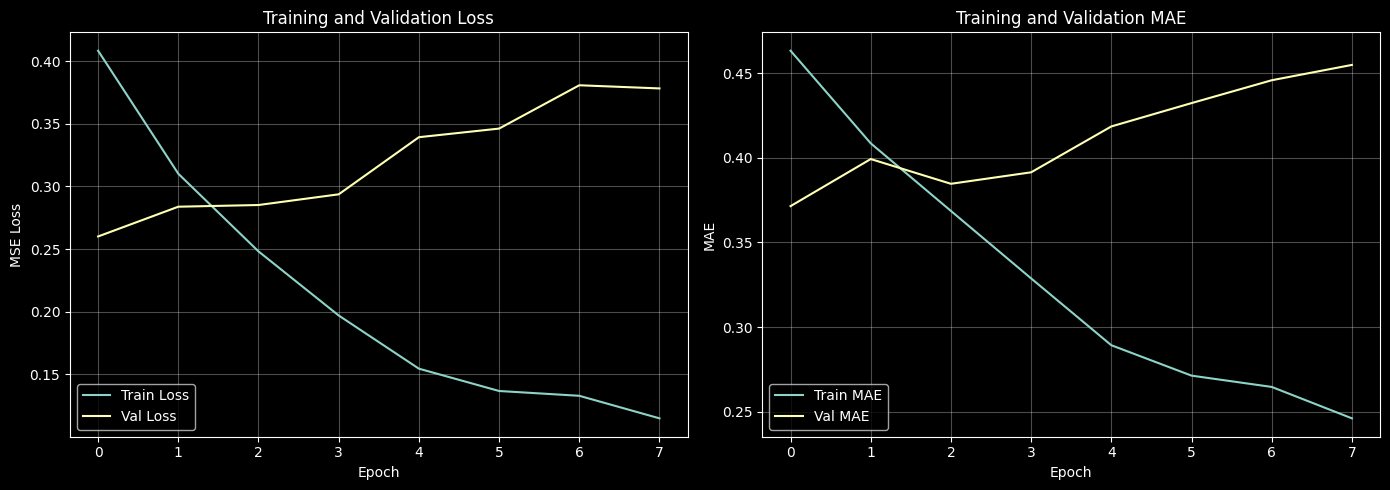

In [36]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history["loss"], label="Train Loss")
ax1.plot(history.history["val_loss"], label="Val Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("MSE Loss")
ax1.set_title("Training and Validation Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history["mae"], label="Train MAE")
ax2.plot(history.history["val_mae"], label="Val MAE")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("MAE")
ax2.set_title("Training and Validation MAE")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Evaluate

In [37]:
test_loss, test_mae = model.evaluate(x_test, y_test)
print(f"Test MSE (scaled): {test_loss:.6f}")
print(f"Test MAE (scaled): {test_mae:.6f}")

# Compute metrics in original units
pred_all_scaled = model.predict(x_test)

pred_all = target_scaler.inverse_transform(
    pred_all_scaled.reshape(-1, 1)
).reshape(-1, FORECAST_HORIZON)

true_all = target_scaler.inverse_transform(
    y_test.reshape(-1, 1)
).reshape(-1, FORECAST_HORIZON)

overall_mae = np.mean(np.abs(pred_all - true_all))
overall_rmse = np.sqrt(np.mean((pred_all - true_all) ** 2))

# MAPE (exclude near-zero values)
mask = np.abs(true_all) > 1.0
overall_mape = np.mean(np.abs((true_all[mask] - pred_all[mask]) / true_all[mask])) * 100

print(f"\nTest Results (original units):")
print(f"  Overall MAE:  {overall_mae:.2f} gCO₂eq/kWh")
print(f"  Overall RMSE: {overall_rmse:.2f} gCO₂eq/kWh")
print(f"  Overall MAPE: {overall_mape:.1f}%")

# ─── Compare with v1 ───
print(f"\n{'='*50}")
print(f"  Comparison with v1 (univariate):")
print(f"  v1 MAE:  20.85 gCO₂eq/kWh  |  v2 MAE:  {overall_mae:.2f} gCO₂eq/kWh")
print(f"  v1 MAPE: 34.5%              |  v2 MAPE: {overall_mape:.1f}%")
print(f"  v1 RMSE: 28.07 gCO₂eq/kWh  |  v2 RMSE: {overall_rmse:.2f} gCO₂eq/kWh")
improvement = (20.85 - overall_mae) / 20.85 * 100
print(f"  MAE improvement: {improvement:.1f}%")
print(f"{'='*50}")


189/189 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.1838 - mae: 0.3146
Test MSE (scaled): 0.183835
Test MAE (scaled): 0.314555
189/189 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step

Test Results (original units):
  Overall MAE:  20.10 gCO₂eq/kWh
  Overall RMSE: 26.35 gCO₂eq/kWh
  Overall MAPE: 36.6%

  Comparison with v1 (univariate):
  v1 MAE:  20.85 gCO₂eq/kWh  |  v2 MAE:  20.10 gCO₂eq/kWh
  v1 MAPE: 34.5%              |  v2 MAPE: 36.6%
  v1 RMSE: 28.07 gCO₂eq/kWh  |  v2 RMSE: 26.35 gCO₂eq/kWh
  MAE improvement: 3.6%


# Save Model

In [38]:
model.save(os.path.join(MODEL_DIR, "final_model.keras"))


# Convert to TFLite

In [39]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
]

tflite_model = converter.convert()

with open(TFLITE_PATH, "wb") as f:
    f.write(tflite_model)

size_kb = os.path.getsize(TFLITE_PATH) / 1024
print(f"TFLite model saved: {TFLITE_PATH} ({size_kb:.1f} KB)")


INFO:tensorflow:Assets written to: C:\Users\jbro9\AppData\Local\Temp\tmpqbaolv8x\assets


INFO:tensorflow:Assets written to: C:\Users\jbro9\AppData\Local\Temp\tmpqbaolv8x\assets


Saved artifact at 'C:\Users\jbro9\AppData\Local\Temp\tmpqbaolv8x'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 168, 16), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 24), dtype=tf.float32, name=None)
Captures:
  2017881048848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2017881050576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2017881049808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2017881049616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2017881050384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2017881050192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2017881051344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2017881049424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2017881050960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2017881051920: TensorSpec(shape=(), dtype=tf.resource, name=None)
TFLite mod

# Save Hyperparameters

In [40]:
params = {
    "model": "LSTM_v2",
    "window_size": WINDOW_SIZE,
    "forecast_horizon": FORECAST_HORIZON,
    "hidden_size": HIDDEN_SIZE,
    "num_layers": NUM_LAYERS,
    "dropout": DROPOUT,
    "learning_rate": LEARNING_RATE,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "features": FEATURES,
    "num_features": len(FEATURES),
    "test_mae": float(overall_mae),
    "test_rmse": float(overall_rmse),
    "test_mape": float(overall_mape),
}

with open("model_params_lstm_v2.json", "w") as f:
    json.dump(params, f, indent=4)

print("Training complete.")


Training complete.


# One Random 24h Forecast

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


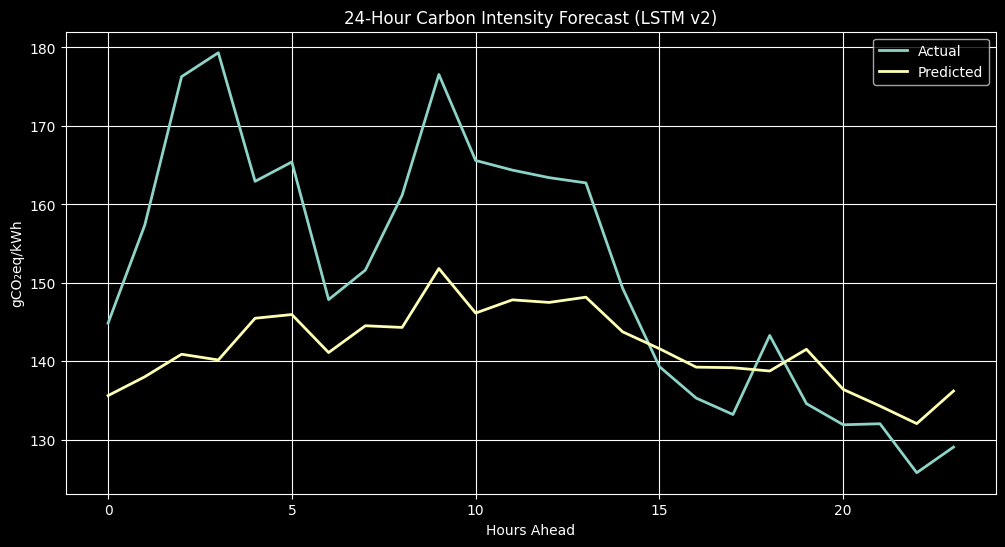

Sample MAE: 12.97 gCO₂eq/kWh


In [41]:
idx = np.random.randint(0, len(x_test))

input_sample = x_test[idx:idx+1]
true_future_scaled = y_test[idx]

pred_scaled = model.predict(input_sample)[0]

true_future = target_scaler.inverse_transform(
    true_future_scaled.reshape(-1, 1)
).flatten()

pred_future = target_scaler.inverse_transform(
    pred_scaled.reshape(-1, 1)
).flatten()

plt.figure(figsize=(12, 6))
hours = np.arange(FORECAST_HORIZON)

plt.plot(hours, true_future, label="Actual", linewidth=2)
plt.plot(hours, pred_future, label="Predicted", linewidth=2)

plt.title("24-Hour Carbon Intensity Forecast (LSTM v2)")
plt.xlabel("Hours Ahead")
plt.ylabel("gCO₂eq/kWh")
plt.legend()
plt.grid(True)
plt.show()

sample_mae = np.mean(np.abs(true_future - pred_future))
print(f"Sample MAE: {sample_mae:.2f} gCO₂eq/kWh")


# Best 3-Hour Charging Window

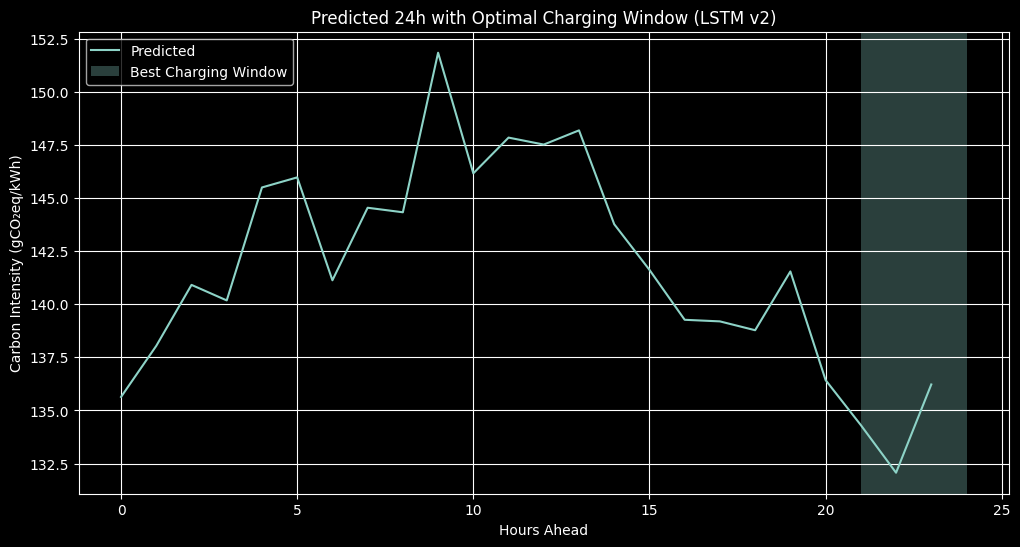

Best charging window: hour 21 to 24


In [42]:
window_size = 3

rolling_avg = np.convolve(
    pred_future,
    np.ones(window_size) / window_size,
    mode='valid'
)

best_start = np.argmin(rolling_avg)
best_end = best_start + window_size

plt.figure(figsize=(12, 6))
plt.plot(hours, pred_future, label="Predicted")

plt.axvspan(best_start, best_end,
            alpha=0.3,
            label="Best Charging Window")

plt.title("Predicted 24h with Optimal Charging Window (LSTM v2)")
plt.xlabel("Hours Ahead")
plt.ylabel("Carbon Intensity (gCO₂eq/kWh)")
plt.legend()
plt.grid(True)
plt.show()

print(f"Best charging window: hour {best_start} to {best_end}")


# Evaluate Error Per Forecast Hour

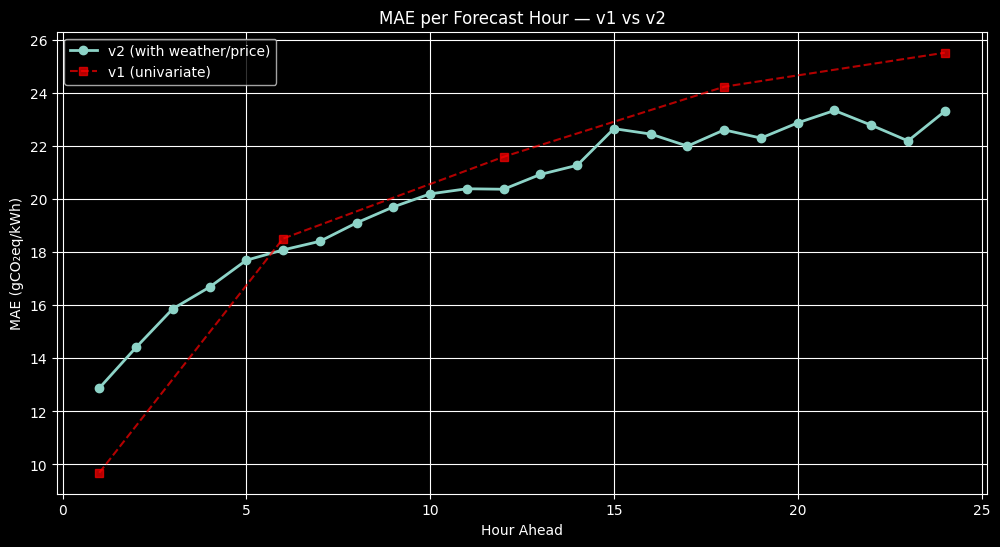

Per-hour MAE comparison:
  Hour        v2        v1    Change
------------------------------------
    1     12.88      9.69    -32.9%
    6     18.08     18.51     +2.3%
   12     20.37     21.59     +5.7%
   18     22.60     24.23     +6.7%
   24     23.30     25.51     +8.7%


In [43]:
mae_per_hour = np.mean(np.abs(pred_all - true_all), axis=0)

# v1 values for comparison
v1_mae_per_hour = [9.69, None, None, None, None, 18.51, 
                   None, None, None, None, None, 21.59,
                   None, None, None, None, None, 24.23,
                   None, None, None, None, None, 25.51]

plt.figure(figsize=(12, 6))
plt.plot(range(1, FORECAST_HORIZON+1), mae_per_hour, marker='o', linewidth=2, label="v2 (with weather/price)")

# Plot v1 reference points
v1_hours = [1, 6, 12, 18, 24]
v1_values = [9.69, 18.51, 21.59, 24.23, 25.51]
plt.plot(v1_hours, v1_values, 'r--', marker='s', linewidth=1.5, alpha=0.7, label="v1 (univariate)")

plt.title("MAE per Forecast Hour — v1 vs v2")
plt.xlabel("Hour Ahead")
plt.ylabel("MAE (gCO₂eq/kWh)")
plt.legend()
plt.grid(True)
plt.show()

print("Per-hour MAE comparison:")
print(f"{'Hour':>6s}  {'v2':>8s}  {'v1':>8s}  {'Change':>8s}")
print("-" * 36)
for h in [0, 5, 11, 17, 23]:
    v1_val = v1_values[v1_hours.index(h+1)] if (h+1) in v1_hours else None
    v2_val = mae_per_hour[h]
    if v1_val:
        change = (v1_val - v2_val) / v1_val * 100
        print(f"  {h+1:3d}   {v2_val:7.2f}   {v1_val:7.2f}   {change:+6.1f}%")
    else:
        print(f"  {h+1:3d}   {v2_val:7.2f}")


# Full 24h Forecast Distribution

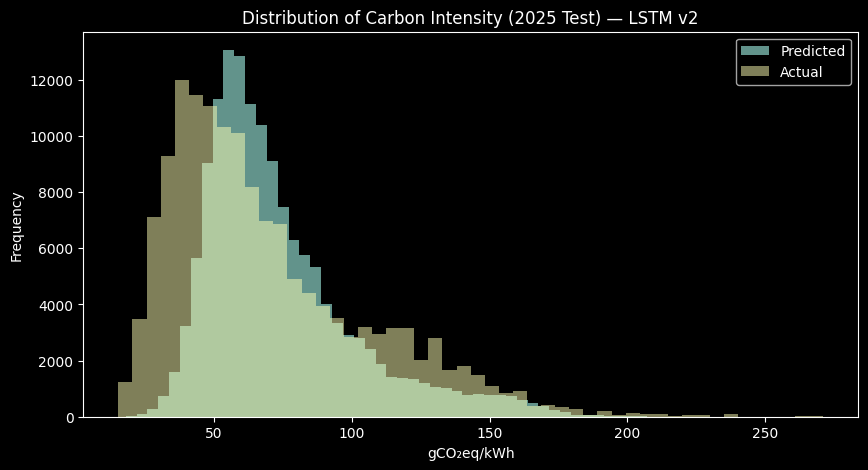

In [44]:
plt.figure(figsize=(10, 5))
plt.hist(pred_all.flatten(), bins=50, alpha=0.7, label="Predicted")
plt.hist(true_all.flatten(), bins=50, alpha=0.5, label="Actual")
plt.title("Distribution of Carbon Intensity (2025 Test) — LSTM v2")
plt.xlabel("gCO₂eq/kWh")
plt.ylabel("Frequency")
plt.legend()
plt.show()


# Seasonal Performance

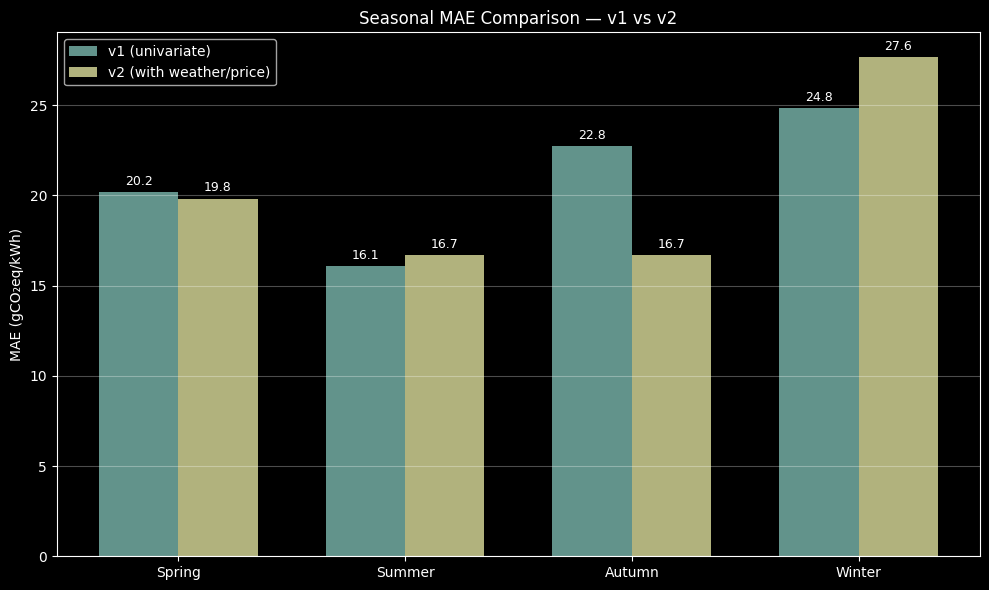

Seasonal MAE comparison:
  Spring  : v1=20.18  v2=19.82  (+1.8%)
  Summer  : v1=16.07  v2=16.70  (-3.9%)
  Autumn  : v1=22.75  v2=16.70  (+26.6%)
  Winter  : v1=24.84  v2=27.65  (-11.3%)


In [45]:
test_dates = test.iloc[WINDOW_SIZE:len(test)-FORECAST_HORIZON]["Datetime (UTC)"]

summer_mask = test_dates.dt.month.isin([6, 7, 8]).values
winter_mask = test_dates.dt.month.isin([12, 1, 2]).values
spring_mask = test_dates.dt.month.isin([3, 4, 5]).values
autumn_mask = test_dates.dt.month.isin([9, 10, 11]).values

summer_mae = np.mean(np.abs(pred_all[summer_mask] - true_all[summer_mask]))
winter_mae = np.mean(np.abs(pred_all[winter_mask] - true_all[winter_mask]))
spring_mae = np.mean(np.abs(pred_all[spring_mask] - true_all[spring_mask]))
autumn_mae = np.mean(np.abs(pred_all[autumn_mask] - true_all[autumn_mask]))

# v1 values for comparison
v1_seasonal = {"Spring": 20.18, "Summer": 16.07, "Autumn": 22.75, "Winter": 24.84}

seasons = ["Spring", "Summer", "Autumn", "Winter"]
v2_maes = [spring_mae, summer_mae, autumn_mae, winter_mae]

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(seasons))
width = 0.35

bars1 = ax.bar(x - width/2, [v1_seasonal[s] for s in seasons], width, label="v1 (univariate)", alpha=0.7)
bars2 = ax.bar(x + width/2, v2_maes, width, label="v2 (with weather/price)", alpha=0.7)

ax.set_ylabel("MAE (gCO₂eq/kWh)")
ax.set_title("Seasonal MAE Comparison — v1 vs v2")
ax.set_xticks(x)
ax.set_xticklabels(seasons)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

# Add value labels
for bar in bars1:
    ax.annotate(f'{bar.get_height():.1f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.1f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("Seasonal MAE comparison:")
for s, v2, v1 in zip(seasons, v2_maes, [v1_seasonal[s] for s in seasons]):
    change = (v1 - v2) / v1 * 100
    print(f"  {s:8s}: v1={v1:.2f}  v2={v2:.2f}  ({change:+.1f}%)")


# Scatter: Predicted vs Actual

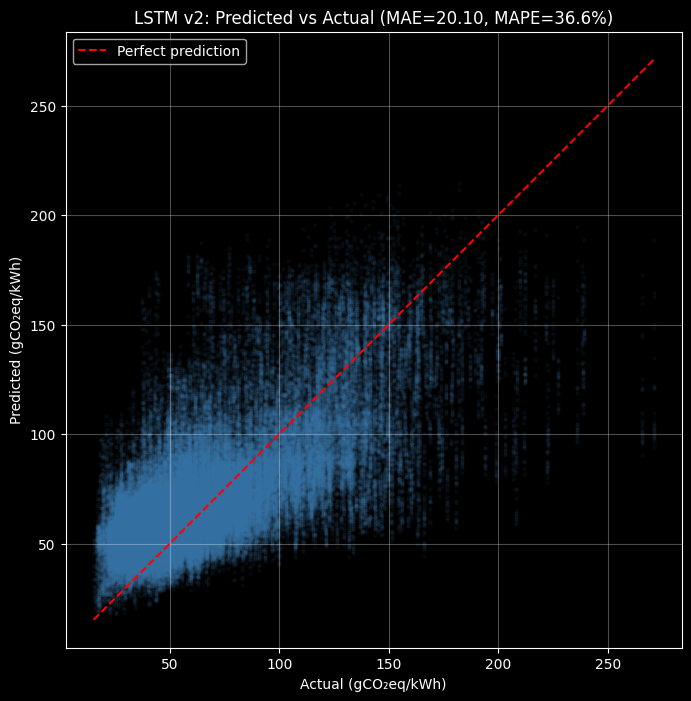

In [46]:
plt.figure(figsize=(8, 8))
pf = pred_all.flatten()
tf_ = true_all.flatten()
plt.scatter(tf_, pf, alpha=0.05, s=5, color="steelblue")
lims = [min(tf_.min(), pf.min()), max(tf_.max(), pf.max())]
plt.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
plt.xlabel("Actual (gCO₂eq/kWh)")
plt.ylabel("Predicted (gCO₂eq/kWh)")
plt.title(f"LSTM v2: Predicted vs Actual (MAE={overall_mae:.2f}, MAPE={overall_mape:.1f}%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.gca().set_aspect("equal")
plt.show()
